Cell 1 — Setup and load everything

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import torch
from pathlib import Path

sys.path.append(str(Path("../src/models").resolve()))
sys.path.append(str(Path("../src/data").resolve()))
sys.path.append(str(Path("../src/evaluation").resolve()))

from cnn import HeatSurrogateCNN
from dataset import load_dataset
from metrics import compute_all_metrics, mse, mae, rmse, relative_l2, max_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load best model
checkpoint = torch.load("../results/best_model.pt", map_location=device)
model = HeatSurrogateCNN(n_filters=32).to(device)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print(f"Model loaded — best epoch: {checkpoint['epoch']}, "
      f"val loss: {checkpoint['val_loss']:.2e}")

# load dataset
_, _, test_ds, metadata = load_dataset("../data/heat_dataset.npz")
print(f"Test samples: {len(test_ds)}")

Model loaded — best epoch: 19, val loss: 7.28e-06
Dataset loaded successfully.
  Train : 8000 samples
  Val   : 1000 samples
  Test  : 1000 samples
  Input shape per sample : torch.Size([1, 64, 64])
  Metadata: {'n_samples': 10000, 'N': 64, 'L': 1.0, 'alpha': 0.01, 'dx': 0.015873015873015872, 'dt': 0.005668934240362811, 'r': 0.22499999999999998, 'stride': 10, 'seed': 42, 'max_blobs': 3, 'n_train': 8000, 'n_val': 1000, 'n_test': 1000, 'physical_dt_per_cnn_step': 0.05668934240362811}
Test samples: 1000


Cell 2 — Run inference on entire test set

In [2]:
all_inputs  = []
all_targets = []
all_preds   = []

with torch.no_grad():
    for i in range(len(test_ds)):
        inp, tgt = test_ds[i]
        pred = model(inp.unsqueeze(0).to(device))

        all_inputs.append(inp.squeeze().cpu().numpy())
        all_targets.append(tgt.squeeze().cpu().numpy())
        all_preds.append(pred.squeeze().cpu().numpy())

inputs  = np.array(all_inputs)    # (1000, 64, 64)
targets = np.array(all_targets)   # (1000, 64, 64)
preds   = np.array(all_preds)     # (1000, 64, 64)

print(f"Inference complete.")
print(f"Predictions shape : {preds.shape}")
print(f"Prediction range  : [{preds.min():.5f}, {preds.max():.5f}]")
print(f"Target range      : [{targets.min():.5f}, {targets.max():.5f}]")

Inference complete.
Predictions shape : (1000, 64, 64)
Prediction range  : [-0.12322, 0.98612]
Target range      : [0.00000, 1.00000]


Cell 3 — Compute all metrics

In [3]:
per_sample, aggregate = compute_all_metrics(preds, targets)

print("=" * 60)
print("SCIENTIFIC EVALUATION — TEST SET (1000 samples)")
print("=" * 60)

metrics_to_print = ["mse", "mae", "rmse", "rel_l2", "max_ae"]
labels = {
    "mse"    : "MSE",
    "mae"    : "MAE",
    "rmse"   : "RMSE",
    "rel_l2" : "Relative L2 Error",
    "max_ae" : "Max Absolute Error",
}

for k in metrics_to_print:
    stats = aggregate[k]
    print(f"\n{labels[k]}:")
    print(f"  Mean   : {stats['mean']:.6f}")
    print(f"  Std    : {stats['std']:.6f}")
    print(f"  Median : {stats['median']:.6f}")
    print(f"  Min    : {stats['min']:.6f}")
    print(f"  Max    : {stats['max']:.6f}")
    print(f"  95th % : {stats['p95']:.6f}")

# save to json for paper
with open("../results/test_metrics.json", "w") as f:
    json.dump(aggregate, f, indent=2)
print("\n✓ Metrics saved to results/test_metrics.json")

SCIENTIFIC EVALUATION — TEST SET (1000 samples)

MSE:
  Mean   : 0.000007
  Std    : 0.000004
  Median : 0.000006
  Min    : 0.000004
  Max    : 0.000092
  95th % : 0.000013

MAE:
  Mean   : 0.002249
  Std    : 0.000231
  Median : 0.002195
  Min    : 0.001799
  Max    : 0.003939
  95th % : 0.002679

RMSE:
  Mean   : 0.002687
  Std    : 0.000514
  Median : 0.002526
  Min    : 0.002061
  Max    : 0.009575
  95th % : 0.003653

Relative L2 Error:
  Mean   : 0.021068
  Std    : 0.013747
  Median : 0.016128
  Min    : 0.010132
  Max    : 0.140401
  95th % : 0.048139

Max Absolute Error:
  Mean   : 0.014930
  Std    : 0.007312
  Median : 0.013435
  Min    : 0.006378
  Max    : 0.123218
  95th % : 0.026758

✓ Metrics saved to results/test_metrics.json


Cell 4 — Error distribution plots

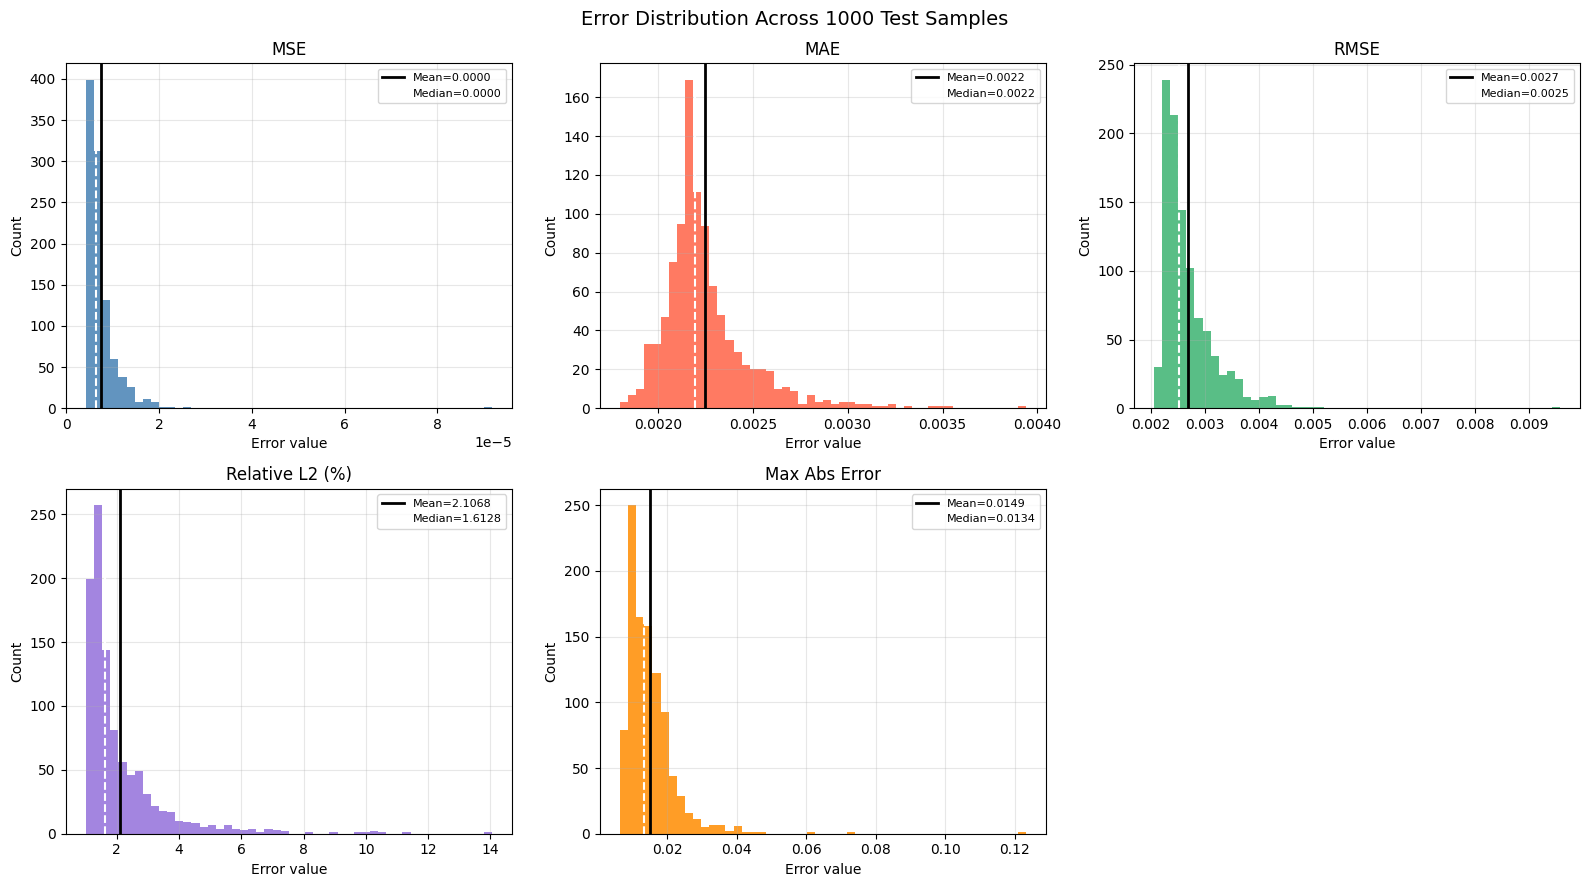

✓ Saved figures/milestone6_error_distributions.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

metric_data = {
    "MSE"              : per_sample["mse"],
    "MAE"              : per_sample["mae"],
    "RMSE"             : per_sample["rmse"],
    "Relative L2 (%)"  : per_sample["rel_l2"] * 100,
    "Max Abs Error"    : per_sample["max_ae"],
}

colors = ["steelblue", "tomato", "mediumseagreen", "mediumpurple", "darkorange"]

for ax, (label, data), color in zip(axes.flatten(), metric_data.items(), colors):
    ax.hist(data, bins=50, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(np.mean(data),   color="black",  linestyle="-",  linewidth=2,
               label=f"Mean={np.mean(data):.4f}")
    ax.axvline(np.median(data), color="white",  linestyle="--", linewidth=1.5,
               label=f"Median={np.median(data):.4f}")
    ax.set_title(label)
    ax.set_xlabel("Error value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[1, 2].axis("off")   # leave last panel empty

plt.suptitle("Error Distribution Across 1000 Test Samples", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/milestone6_error_distributions.png", dpi=150)
plt.show()
print("✓ Saved figures/milestone6_error_distributions.png")

Cell 5 — Mean spatial error field

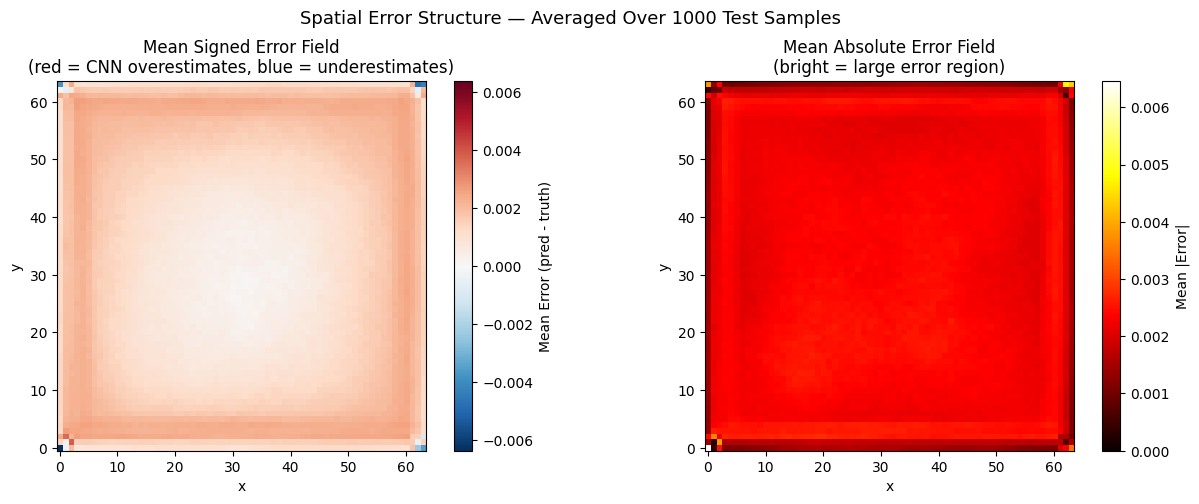

Max mean signed error    : 0.003880
Min mean signed error    : -0.006378
Max mean absolute error  : 0.006450
Mean absolute error field mean: 0.002249


In [5]:
mean_err_field     = per_sample["mean_error_field"]      # signed: bias
mean_abs_err_field = per_sample["mean_abs_error_field"]  # unsigned: magnitude

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# signed error — reveals systematic bias (CNN consistently over or under predicts)
im0 = axes[0].imshow(
    mean_err_field,
    origin="lower", cmap="RdBu_r",
    vmin=-np.abs(mean_err_field).max(),
    vmax= np.abs(mean_err_field).max()
)
axes[0].set_title("Mean Signed Error Field\n"
                  "(red = CNN overestimates, blue = underestimates)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], label="Mean Error (pred - truth)")

# absolute error — reveals where errors are largest regardless of sign
im1 = axes[1].imshow(
    mean_abs_err_field,
    origin="lower", cmap="hot",
    vmin=0
)
axes[1].set_title("Mean Absolute Error Field\n"
                  "(bright = large error region)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1], label="Mean |Error|")

plt.suptitle("Spatial Error Structure — Averaged Over 1000 Test Samples", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/milestone6_spatial_error.png", dpi=150)
plt.show()

print(f"Max mean signed error    : {mean_err_field.max():.6f}")
print(f"Min mean signed error    : {mean_err_field.min():.6f}")
print(f"Max mean absolute error  : {mean_abs_err_field.max():.6f}")
print(f"Mean absolute error field mean: {mean_abs_err_field.mean():.6f}")

Cell 6 — Side-by-side comparison with matched color scale

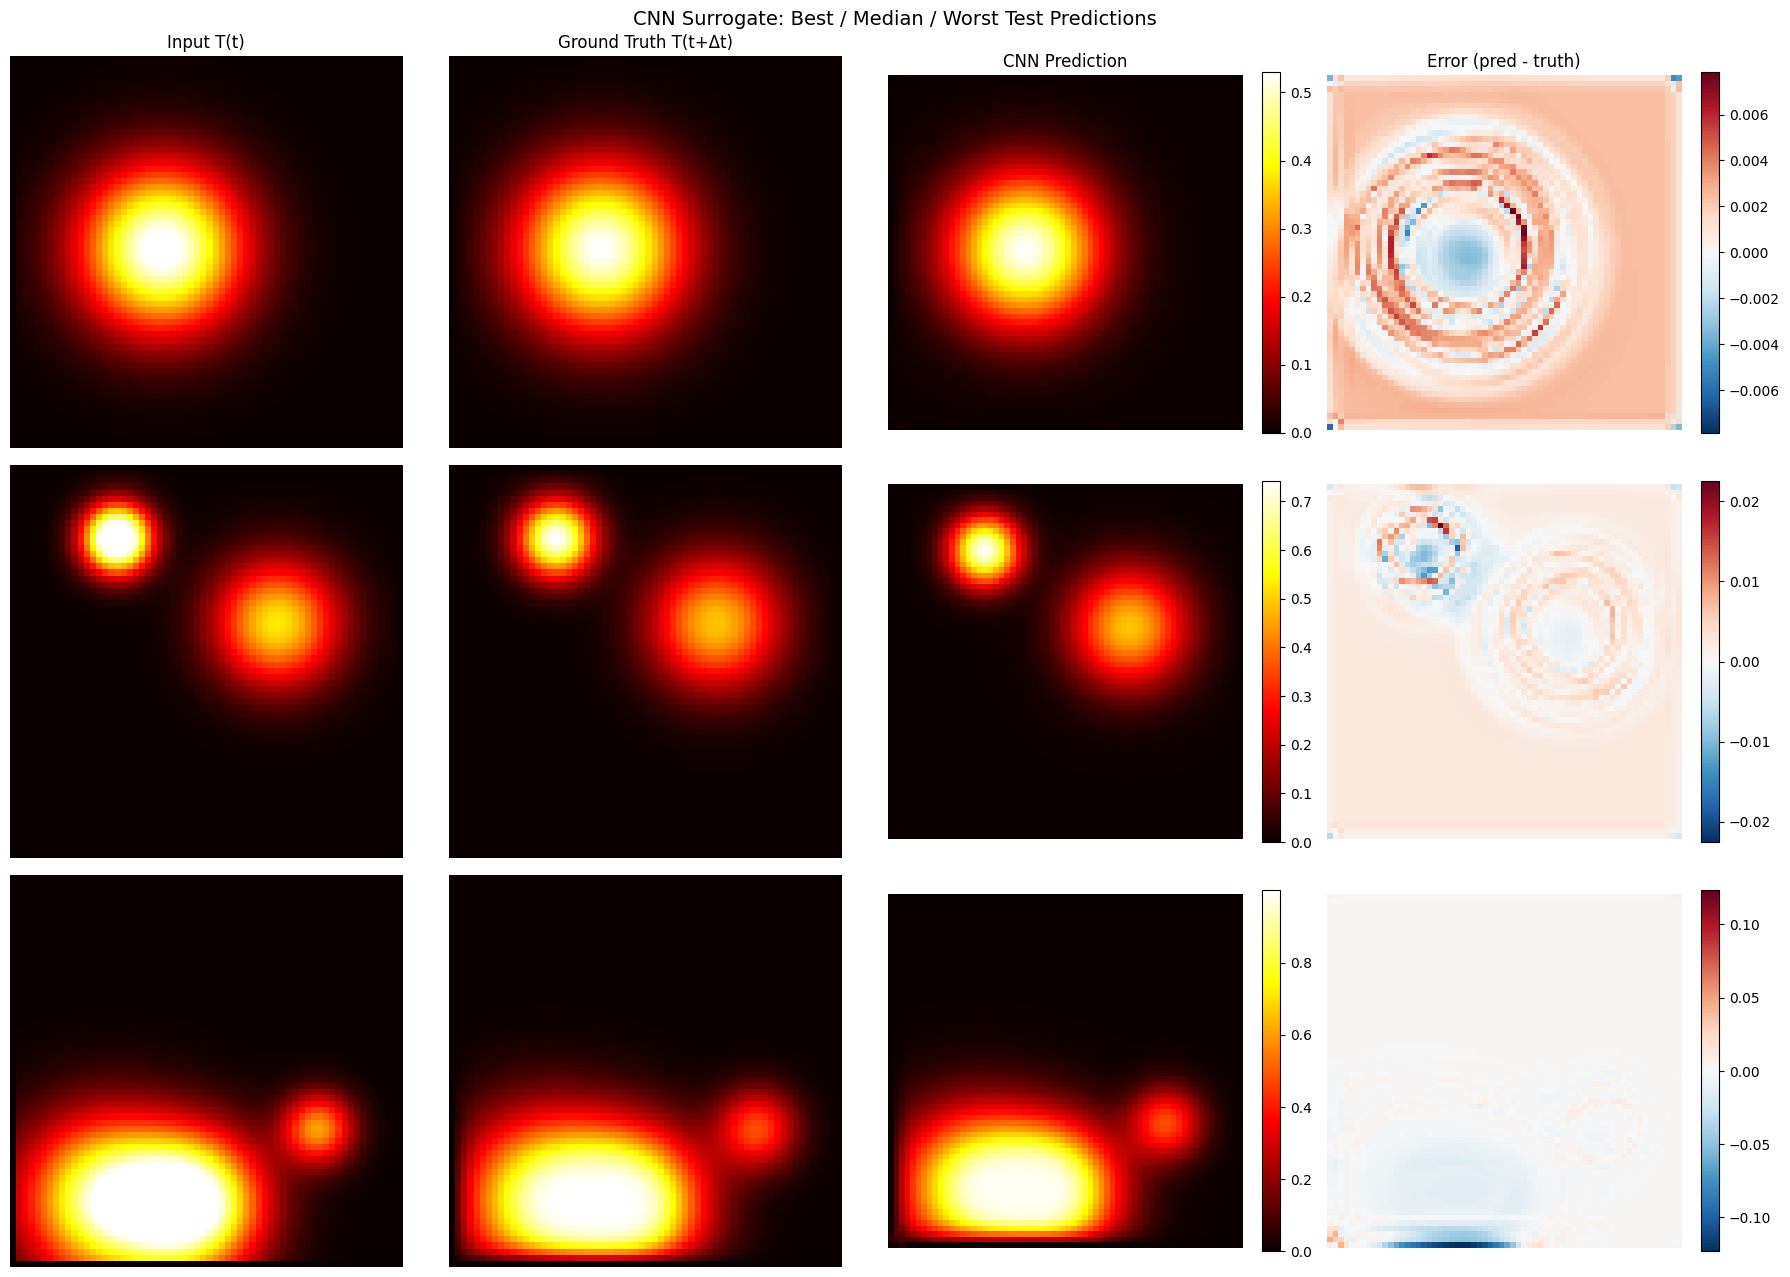

✓ Saved figures/milestone6_best_median_worst.png

Best   sample idx=215,   MSE=4.25e-06
Median sample idx=718, MSE=6.38e-06
Worst  sample idx=988,  MSE=9.17e-05


In [6]:
# pick 3 representative test samples:
# best prediction, median prediction, worst prediction
mse_vals   = per_sample["mse"]
idx_best   = int(np.argmin(mse_vals))
idx_median = int(np.argsort(mse_vals)[len(mse_vals)//2])
idx_worst  = int(np.argmax(mse_vals))

sample_indices = [idx_best, idx_median, idx_worst]
row_labels     = [
    f"Best prediction\n(MSE={mse_vals[idx_best]:.2e})",
    f"Median prediction\n(MSE={mse_vals[idx_median]:.2e})",
    f"Worst prediction\n(MSE={mse_vals[idx_worst]:.2e})",
]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))

for row, (idx, row_label) in enumerate(zip(sample_indices, row_labels)):
    inp  = inputs[idx]
    tgt  = targets[idx]
    pred = preds[idx]
    err  = pred - tgt

    # fixed color scale for honest comparison
    vmin = 0.0
    vmax = max(tgt.max(), pred.max())

    im0 = axes[row, 0].imshow(inp,  origin="lower", cmap="hot",
                               vmin=vmin, vmax=vmax)
    im1 = axes[row, 1].imshow(tgt,  origin="lower", cmap="hot",
                               vmin=vmin, vmax=vmax)
    im2 = axes[row, 2].imshow(pred, origin="lower", cmap="hot",
                               vmin=vmin, vmax=vmax)

    err_scale = np.abs(err).max()
    im3 = axes[row, 3].imshow(err, origin="lower", cmap="RdBu_r",
                               vmin=-err_scale, vmax=err_scale)

    axes[row, 0].set_title(f"Input T(t)" if row == 0 else "")
    axes[row, 1].set_title("Ground Truth T(t+Δt)" if row == 0 else "")
    axes[row, 2].set_title("CNN Prediction" if row == 0 else "")
    axes[row, 3].set_title("Error (pred - truth)" if row == 0 else "")

    axes[row, 0].set_ylabel(row_label, fontsize=9)

    for ax in axes[row, :3]:
        ax.axis("off")
    axes[row, 3].axis("off")

    # colorbars only on last column
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)
    plt.colorbar(im3, ax=axes[row, 3], fraction=0.046)

plt.suptitle("CNN Surrogate: Best / Median / Worst Test Predictions", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/milestone6_best_median_worst.png", dpi=150)
plt.show()
print(f"✓ Saved figures/milestone6_best_median_worst.png")
print(f"\nBest   sample idx={idx_best},   MSE={mse_vals[idx_best]:.2e}")
print(f"Median sample idx={idx_median}, MSE={mse_vals[idx_median]:.2e}")
print(f"Worst  sample idx={idx_worst},  MSE={mse_vals[idx_worst]:.2e}")

Cell 7 — Does error correlate with input complexity?

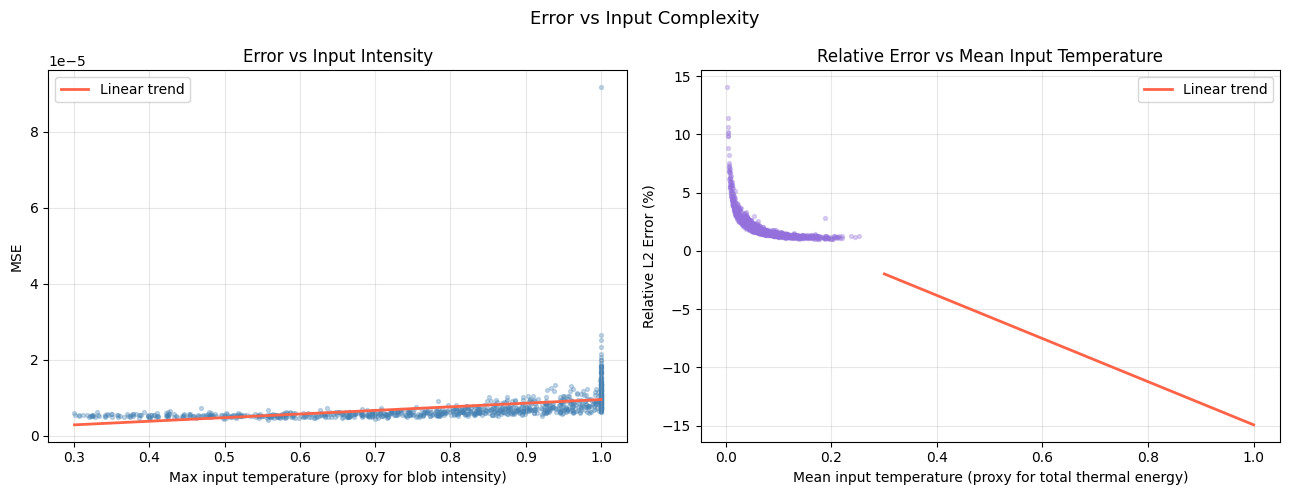

Correlation: input max  vs MSE        = 0.4743
Correlation: input mean vs Rel L2     = -0.6632

Interpretation:
  Positive correlation → harder inputs cause larger errors


In [7]:
# proxy for complexity: max temperature in input (higher = more intense blob)
input_max  = inputs.max(axis=(1,2))     # (1000,)
input_mean = inputs.mean(axis=(1,2))    # (1000,)
mse_vals   = per_sample["mse"]          # (1000,)
rel_vals   = per_sample["rel_l2"]       # (1000,)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(input_max, mse_vals, alpha=0.3, s=8, color="steelblue")
axes[0].set_xlabel("Max input temperature (proxy for blob intensity)")
axes[0].set_ylabel("MSE")
axes[0].set_title("Error vs Input Intensity")
axes[0].grid(True, alpha=0.3)

# add trend line
z = np.polyfit(input_max, mse_vals, 1)
p = np.poly1d(z)
x_line = np.linspace(input_max.min(), input_max.max(), 100)
axes[0].plot(x_line, p(x_line), color="tomato", linewidth=2, label="Linear trend")
axes[0].legend()

axes[1].scatter(input_mean, rel_vals * 100, alpha=0.3, s=8, color="mediumpurple")
axes[1].set_xlabel("Mean input temperature (proxy for total thermal energy)")
axes[1].set_ylabel("Relative L2 Error (%)")
axes[1].set_title("Relative Error vs Mean Input Temperature")
axes[1].grid(True, alpha=0.3)

z2 = np.polyfit(input_mean, rel_vals * 100, 1)
p2 = np.poly1d(z2)
axes[1].plot(x_line, p2(x_line), color="tomato", linewidth=2, label="Linear trend")
axes[1].legend()

plt.suptitle("Error vs Input Complexity", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/milestone6_error_vs_complexity.png", dpi=150)
plt.show()

# correlation coefficients
corr_mse = np.corrcoef(input_max, mse_vals)[0,1]
corr_rel = np.corrcoef(input_mean, rel_vals)[0,1]
print(f"Correlation: input max  vs MSE        = {corr_mse:.4f}")
print(f"Correlation: input mean vs Rel L2     = {corr_rel:.4f}")
print()
print("Interpretation:")
print(f"  {'Positive correlation → harder inputs cause larger errors' if corr_mse > 0.1 else 'Weak correlation → error is relatively independent of input intensity'}")

Cell 8 — Summary table for paper

In [8]:
print("=" * 65)
print("TABLE 1 — CNN SURROGATE EVALUATION ON TEST SET (n=1000)")
print("=" * 65)
print(f"{'Metric':<25} {'Mean':>10} {'Std':>10} {'Median':>10} {'95th %':>10}")
print("-" * 65)

rows = [
    ("MSE",               "mse",     1),
    ("MAE",               "mae",     1),
    ("RMSE",              "rmse",    1),
    ("Relative L2 (%)",   "rel_l2",  100),
    ("Max Abs Error",     "max_ae",  1),
]

for label, key, scale in rows:
    s = aggregate[key]
    print(f"{label:<25} "
          f"{s['mean']*scale:>10.5f} "
          f"{s['std']*scale:>10.5f} "
          f"{s['median']*scale:>10.5f} "
          f"{s['p95']*scale:>10.5f}")

print("=" * 65)
print("\nThis table goes directly into your paper as Table 1.")
print("Report Relative L2 (%) as your headline accuracy metric.")

TABLE 1 — CNN SURROGATE EVALUATION ON TEST SET (n=1000)
Metric                          Mean        Std     Median     95th %
-----------------------------------------------------------------
MSE                          0.00001    0.00000    0.00001    0.00001
MAE                          0.00225    0.00023    0.00220    0.00268
RMSE                         0.00269    0.00051    0.00253    0.00365
Relative L2 (%)              2.10680    1.37471    1.61275    4.81389
Max Abs Error                0.01493    0.00731    0.01344    0.02676

This table goes directly into your paper as Table 1.
Report Relative L2 (%) as your headline accuracy metric.
